# Logistic Regression base model

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from src.data import load_raw_tables, prepare_delivery_events, build_master_df, add_engineering_features
from src.preprocessing_data import split_data, scale_data, prepare_training_data
from src.data_load import apply_pca

In [2]:
base_path = r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1"
tables = load_raw_tables(base_path)
delivery_events = prepare_delivery_events(tables["delivery_events"])
df = build_master_df(
    delivery_events,
    tables["trips"],
    tables["loads"],
    tables["drivers"],
    tables["trucks"],
    tables["routes"],
    tables["customers"]
)
df = add_engineering_features(df)

In [3]:
# Removing rows with missing values in 'CustomerID' and 'Description' columns
df = df.dropna(subset=['is_home_terminal', 'years_experience','efficiency_ratio','truck_age_at_event'])

In [4]:
# Final Column Selection (The Optimized List)
final_columns = [
    'on_time_flag', 
    'location_state',
    'facility_congestion_score', 
    'facility_detention_avg',
    'hour_of_day', 
    'day_of_week', 
    'event_type',
    'booking_type',
    'weight_lbs', 
    'pieces',
    'revenue',
    'load_type',
    'years_experience', 
    'truck_age_at_event',
    'average_mpg', 
    'idle_time_hours',
    'distance_deviation',
    'is_home_terminal', 
    'detention_risk_index', 
    'efficiency_ratio', 
    'revenue_density',
    'is_winter'
]

In [5]:
# Separate Features and Target
categorical_cols = ['day_of_week', 'event_type', 'booking_type', 'load_type','location_state']
numeric_cols = [
    'facility_congestion_score', 'facility_detention_avg', 'hour_of_day', 
    'weight_lbs', 'pieces', 'revenue', 'years_experience', 
    'truck_age_at_event', 'average_mpg', 'idle_time_hours', 'distance_deviation',
    'is_home_terminal', 'detention_risk_index', 'efficiency_ratio', 'revenue_density','is_winter'
]
target = 'on_time_flag'

In [6]:
# Create df for model training
df_model = df[categorical_cols + numeric_cols + [target]].copy()

In [7]:
# ONE-HOT ENCODING to convertstext categories into 0/1 columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

In [8]:
X_train_scaled, X_test_scaled, y_train, y_test, imputer, scaler = prepare_training_data(
    df_encoded, target
)

In [9]:
X_train_pca, X_test_pca, pca = apply_pca(
    X_train_scaled,
    X_test_scaled,
    n_components=21   # or 0.95 if you want automatic selection
)

In [10]:


model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_pca, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_test_pca)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression
Accuracy : 0.5829
Precision: 0.5962
Recall   : 0.7766
F1 Score : 0.6746


In [27]:
from IPython.display import display, HTML
display(HTML("<div style='height:50px;'></div>"))
HTML("<br><br><br>")

report=classification_report(y_test, y_pred)
print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

       False       0.55      0.34      0.42     14556
        True       0.60      0.78      0.67     18269

    accuracy                           0.58     32825
   macro avg       0.57      0.56      0.55     32825
weighted avg       0.57      0.58      0.56     32825




Confusion Matrix:


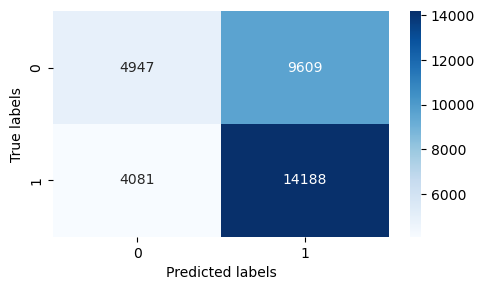

In [31]:
from IPython.display import display, HTML
display(HTML("<div style='height:40px;'></div>"))


print("\nConfusion Matrix:")
cm=confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",          # <-- THIS is the key line
    cmap="Blues"
)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()

plt.show()

In [18]:
from IPython.display import display, HTML
display(HTML("<div style='height:50px;'></div>"))
HTML("<br><br><br>")

results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.58294,0.59621,0.776616,0.674559
